|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 3:</h2>|<h1>PagedAttention<h1>|
|<h2>Section:</h2>|<h1>The block allocator<h1>|
|<h2>Lecture:</h2>|<h1><b>Where the KV memory actually goes, and why most of it is empty<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

# Where the memory goes

Part 1 counted the bytes that a sequence needs. This notebook counts the bytes
that a sequence **holds**. Before vLLM those were very different numbers.

Here is the problem. You must allocate the cache before you know the length of
the reply. The only safe answer is `max_len`, for every request.

In [2]:
# The KV cost per token is arithmetic about the MODEL, not a magic number.
# Two entries (K and V), one per layer, per KV head, per element of head_dim.
LAYERS, KV_HEADS, HEAD_DIM, DTYPE_BYTES = 28, 8, 128, 2      # Qwen3-0.6B, bf16
KV_BYTES = 2 * LAYERS * KV_HEADS * HEAD_DIM * DTYPE_BYTES

lengths = rng.lognormal(mean=np.log(120), sigma=0.9, size=20000).astype(int) + 1
POOL_BYTES = 10e9              # bytes of VRAM left after the weights

print(f'{KV_BYTES/1024:.0f} KB per token, {POOL_BYTES/1e9:.0f} GB of pool')
print(f'median output {np.median(lengths):.0f} tokens, p99 {np.percentile(lengths,99):.0f}')

112 KB per token, 10 GB of pool
median output 120 tokens, p99 960


### One contiguous buffer per sequence, sized for the worst case

In [3]:
MAX_LEN = 2048

bytes_per_sequence = MAX_LEN * KV_BYTES
resident = POOL_BYTES / bytes_per_sequence

print(f'reserve {MAX_LEN} tokens: {bytes_per_sequence/1e6:.0f} MB per sequence')
print(f'that is {resident:.0f} sequences resident, on a {POOL_BYTES/1e9:.0f} GB pool')

reserve 2048 tokens: 235 MB per sequence
that is 43 sequences resident, on a 10 GB pool


In [4]:
sample = rng.choice(lengths, 20000)
used = sample.sum() * KV_BYTES
reserved = len(sample) * MAX_LEN * KV_BYTES

print(f'bytes reserved: {reserved/1e9:8.1f} GB')
print(f'bytes used:     {used/1e9:8.1f} GB')
print(f'\n{100*(1-used/reserved):.1f}% of the KV memory never holds a token')

bytes reserved:   4697.6 GB
bytes used:        414.0 GB

91.2% of the KV memory never holds a token


### Three kinds of waste, and they differ

- **Reserved**: room for tokens that the model has not made yet. A contiguous
  buffer forces this, because it cannot grow into its neighbour.
- **Internal fragmentation**: the tail of the buffer, for a sequence that
  stopped early. This is most of the 90 percent above.
- **External fragmentation**: gaps between buffers, too small for any request.

The vLLM paper measured **60 to 80 percent** waste in real systems. Your own
number depends on your `max_len` guess.

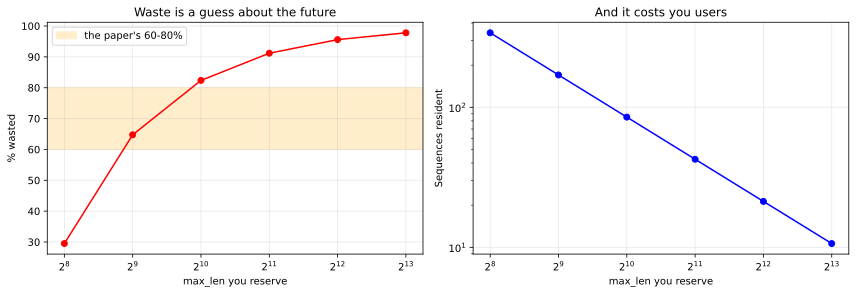

In [5]:
max_lens = np.array([256, 512, 1024, 2048, 4096, 8192])
waste = np.array([1 - sample.sum()/(len(sample)*max_len) for max_len in max_lens])
sequences_resident = np.array([POOL_BYTES/(max_len*KV_BYTES) for max_len in max_lens])

fig, axes = plt.subplots(1, 2, figsize=(12,4.2))
axes[0].plot(max_lens, 100*waste, 'ro-')
axes[0].axhspan(60, 80, color='orange', alpha=.2, label="the paper's 60-80%")
axes[0].set_xscale('log', base=2)
axes[0].set(xlabel='max_len you reserve', ylabel='% wasted',
           title='Waste is a guess about the future')
axes[0].legend()
axes[0].grid(alpha=.3)

axes[1].plot(max_lens, sequences_resident, 'bo-')
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log')
axes[1].set(xlabel='max_len you reserve',
           ylabel='Sequences resident', title='And it costs you users')
axes[1].grid(alpha=.3)
plt.tight_layout()
plt.show()

### See what the fix cannot be

You cannot reserve less. A sequence that outgrows its buffer has nowhere to
go. You cannot reserve more. You already waste most of the memory.

Attack the word **contiguous** instead. A cache that is not one run of memory
can grow a little at a time. It then needs no guess about the future.

That is virtual memory. Engineers solved it in 1961.